In [1]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Image set successfully! Size: (1104, 736, 3)


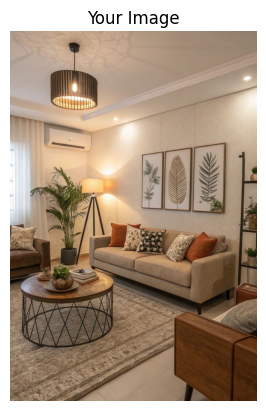

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Load model
checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))

# Load your image
image = Image.open("your_photo.jpg").convert("RGB")
image_np = np.array(image)

# Set image
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image_np)
    print("Image set successfully! Size:", image_np.shape)

plt.imshow(image_np)
plt.title("Your Image")
plt.axis("off")
plt.show()

In [4]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

# Load Grounding DINO
model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to("cuda")

# Define what to detect
TEXT_PROMPT = "plant. couch. table. cushion."

# Run detection
inputs = processor(images=image, text=TEXT_PROMPT, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = grounding_model(**inputs)

# Process results (updated API)
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.4,
    target_sizes=[image.size[::-1]]
)

boxes = results[0]["boxes"]
labels = results[0]["labels"]
scores = results[0]["scores"]

print(f"Detected {len(boxes)} objects:")
for label, score in zip(labels, scores):
    print(f"  - {label}: {score:.2f}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 990/990 [00:00<00:00, 4091.47it/s]


Detected 16 objects:
  - couch: 0.80
  - plant: 0.55
  - plant: 0.58
  - plant: 0.63
  - plant: 0.57
  - plant: 0.55
  - cushion: 0.60
  - table: 0.43
  - cushion: 0.49
  - cushion: 0.48
  - cushion: 0.49
  - couch: 0.46
  - cushion: 0.43
  - cushion: 0.45
  - couch: 0.54
  - cushion: 0.41


C:\Users\payal\AppData\Local\Temp\ipykernel_11652\2740817277.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(masks))


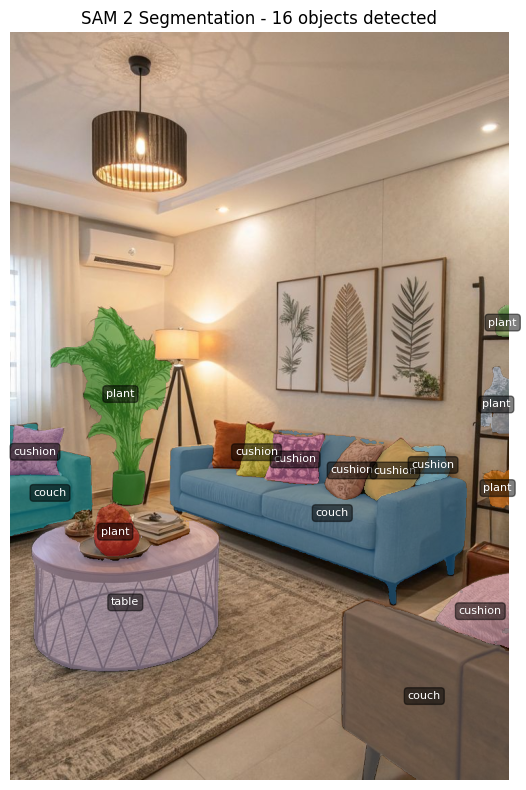

Saved to outputs/my_segmentation_result.jpg


In [5]:
# Run SAM 2 segmentation on detected boxes
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image_np)
    masks, scores_sam, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=boxes.cpu().numpy(),
        multimask_output=False
    )

# Visualize results
def show_masks(image, masks, labels):
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    colors = plt.cm.get_cmap('tab20', len(masks))
    for i, (mask, label) in enumerate(zip(masks, labels)):
        m = mask.squeeze()
        color = colors(i)[:3]
        colored_mask = np.zeros((*m.shape, 4))
        colored_mask[m > 0] = [*color, 0.5]
        plt.imshow(colored_mask)
        # Find center of mask for label
        y, x = np.where(m > 0)
        if len(x) > 0:
            plt.text(x.mean(), y.mean(), label, 
                    color='white', fontsize=8, 
                    ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    plt.title(f"SAM 2 Segmentation - {len(masks)} objects detected")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("outputs/my_segmentation_result.jpg", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to outputs/my_segmentation_result.jpg")

show_masks(image_np, masks, labels)